In [26]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data loading and preproccessing

In [18]:
daydf = pd.read_csv("../data/processed/processed_day.csv")

# chia train 80%, test 20%

split = int(len(daydf) * 0.8)
train = daydf.iloc[:split]
test = daydf.iloc[split:]

# Vì trong dataset lưu các feature dạng số nên dùn one hot encoder 

change = ['season', 'mnth','weekday', 'weathersit']
encoder = OneHotEncoder(
    drop="first",
    sparse_output=False, handle_unknown="ignore")

train_encoded = encoder.fit_transform(train[change])
test_encoded = encoder.transform(test[change])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoder.get_feature_names_out(change),
    index=train.index
)

test_encoded = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(change), index = test.index)

train = train.drop(columns=change)
test = test.drop(columns=change)

train = pd.concat([train, train_encoded], axis=1)
test = pd.concat([test, test_encoded], axis=1)


features = [
    col for col in train.columns
    if col not in [
        "cnt",
        "casual",
        "registered",
        "dteday",
        "instant",
        "Unnamed: 0"
    ]
]
print(features)

target = "cnt"

X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'cnt_lag1', 'cnt_lag7', 'cnt_roll7_mean', 'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3']


## Linear Regression

In [19]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = root_mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)
print(f"Linear regression MAE : {lr_mae:.2f}")
print(f"Linear regression RMSE: {lr_rmse:.2f}")
print(f"Linear regression R2: {lr_r2:.2f}")


Linear regression MAE : 659.12
Linear regression RMSE: 947.21
Linear regression R2: 0.75


## Random Forest

In [20]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)
print(f"Random forest MAE: {rf_mae:.2f}")
print(f"Random forest RMSE: {rf_rmse:.2f}")
print(f"Random forest R2: {rf_r2:.2f}")


Random forest MAE: 783.06
Random forest RMSE: 1035.08
Random forest R2: 0.70


## random forest parameter tuning

In [21]:
for depth in [4, 6, 8, 10, None]:
    for leaf in [1, 5, 10]:
        m = RandomForestRegressor(n_estimators=200, max_depth=depth, min_samples_leaf=leaf, random_state=42, n_jobs=-1)
        m.fit(X_train, y_train)
        mae = mean_absolute_error(y_test, m.predict(X_test))
        print(f"depth={depth}, leaf={leaf}: MAE={mae:.2f}")

depth=4, leaf=1: MAE=869.81
depth=4, leaf=5: MAE=884.89
depth=4, leaf=10: MAE=902.06
depth=6, leaf=1: MAE=802.80
depth=6, leaf=5: MAE=820.82
depth=6, leaf=10: MAE=851.55
depth=8, leaf=1: MAE=788.33
depth=8, leaf=5: MAE=806.72
depth=8, leaf=10: MAE=847.94
depth=10, leaf=1: MAE=783.86
depth=10, leaf=5: MAE=805.18
depth=10, leaf=10: MAE=847.69
depth=None, leaf=1: MAE=783.06
depth=None, leaf=5: MAE=804.48
depth=None, leaf=10: MAE=847.74


## Hist gradient boosting

In [22]:
gb_model = HistGradientBoostingRegressor()
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = root_mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)
print(f"Hist Gradient Boosting MAE: {gb_mae:.2f}")
print(f"Hist Gradient Boosting RMSE: {gb_rmse:.2f}")
print(f"Hist Gradient Boosting R2: {gb_r2:.2f}")

Hist Gradient Boosting MAE: 850.74
Hist Gradient Boosting RMSE: 1084.67
Hist Gradient Boosting R2: 0.67


## Time series split validation

In [23]:
tscv = TimeSeriesSplit(n_splits=3)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_idx, val_idx in tscv.split(X_train):

    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)

    pred = model.predict(X_val)

    mae_scores.append(mean_absolute_error(y_val, pred))
    rmse_scores.append(root_mean_squared_error(y_val, pred))
    r2_scores.append(r2_score(y_val, pred))

print("MAE mỗi fold:", mae_scores)
print("Mean MAE:", np.mean(mae_scores))
print("Std MAE:", np.std(mae_scores))

print("Mean RMSE:", np.mean(rmse_scores))
print("Mean R²:", np.mean(r2_scores))

for i, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    print(f"Fold {i}:")
    print(f"Train size = {len(train_idx)}")
    print(f"Validation size = {len(val_idx)}")
    print(f"\nFold {i}")
    print("Train:",
          train.iloc[train_idx]["dteday"].min(),
          "->",
          train.iloc[train_idx]["dteday"].max())

    print("Validation:",
          train.iloc[val_idx]["dteday"].min(),
          "->",
          train.iloc[val_idx]["dteday"].max())


MAE mỗi fold: [603.9453420856767, 1035.036311806533, 734.5213435085558]
Mean MAE: 791.1676658002551
Std MAE: 180.49277070582514
Mean RMSE: 973.1287673025485
Mean R²: 0.0410423926491181
Fold 1:
Train size = 147
Validation size = 144

Fold 1
Train: 2011-01-08 -> 2011-06-03
Validation: 2011-06-04 -> 2011-10-25
Fold 2:
Train size = 291
Validation size = 144

Fold 2
Train: 2011-01-08 -> 2011-10-25
Validation: 2011-10-26 -> 2012-03-17
Fold 3:
Train size = 435
Validation size = 144

Fold 3
Train: 2011-01-08 -> 2012-03-17
Validation: 2012-03-18 -> 2012-08-08


## Visualization

### Actual vs Prediction (Linear Regresison)

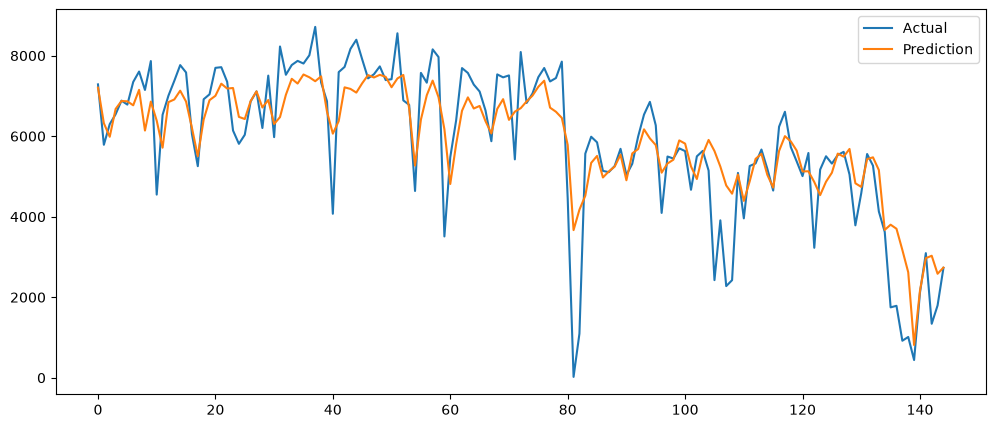

In [24]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(lr_pred, label="Prediction")
plt.legend()

### Residual plot

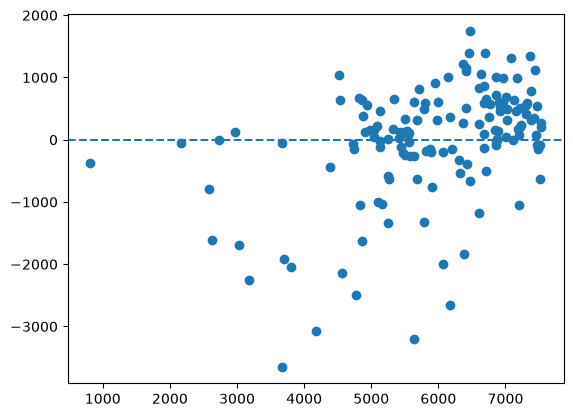

In [28]:
residual = y_test - lr_pred

plt.scatter(lr_pred, residual)
plt.axhline(0, linestyle="--")

### Residual Distribution

<Axes: xlabel='cnt', ylabel='Count'>

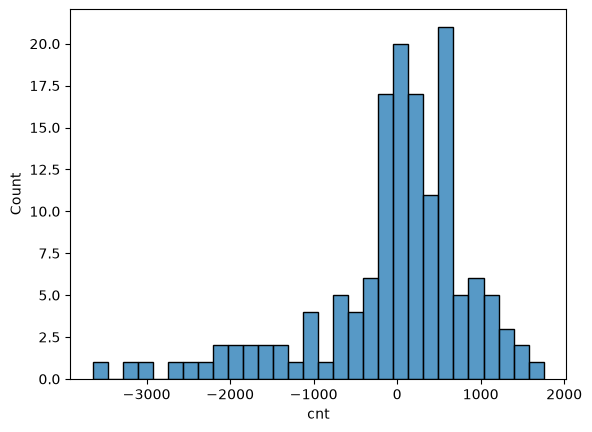

In [29]:
sns.histplot(residual, bins=30)

### Linear Regression Coefficients

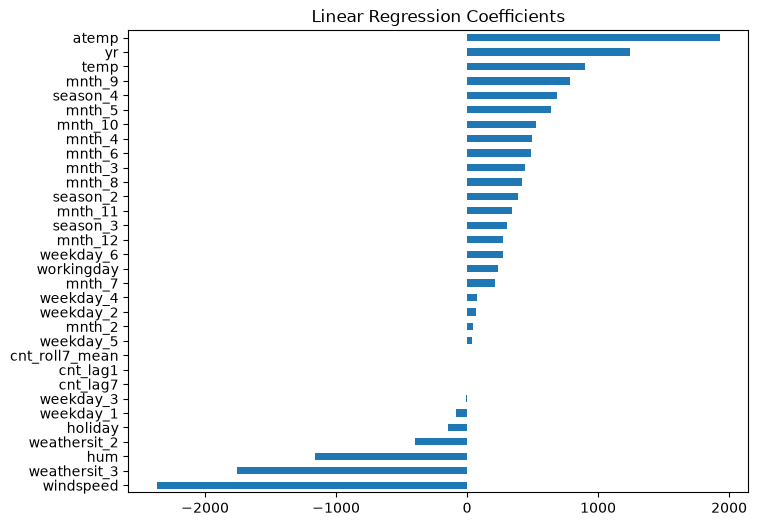

In [32]:
coef = pd.Series(
    lr_model.coef_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,6))
coef.plot.barh()
plt.title("Linear Regression Coefficients")
plt.show()

### Random Forest Feature Importance

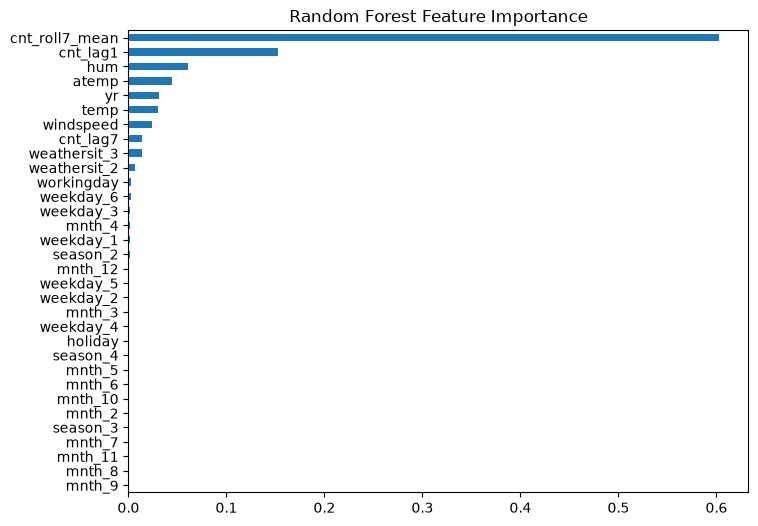

In [33]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(8,6))
importance.plot.barh()
plt.title("Random Forest Feature Importance")
plt.show()

## Comparison

| Model                 |       MAE ↓ |     RMSE ↓ |     R² ↑ | Remarks                                                                  |
| :-------------------- | ----------: | ---------: | -------: | :----------------------------------------------------------------------- |
| Persistence Baseline  |  **878.39** |    1282.32 |     0.53 | Baseline model                                                           |
| Seasonal Baseline     | **1194.73** |    1759.66 |     0.12 | Worse than Persistence                                                   |
| **Linear Regression** |  **659.12** | **947.21** | **0.75** | **Best performing model**                                                |
| Random Forest         |      783.06 |    1035.08 |     0.70 | Better than baseline, but worse than Linear Regression                   |
| HistGradientBoosting  |      850.74 |    1084.67 |     0.67 | Slight improvement over baseline, but lowest performance among ML models |


# Conclusion
- Overall, Linear Regression was selected as the final model because it achieved the lowest prediction error while maintaining good generalization performance.
